REVISIONE DELLA PIPELINE DI DEEP LEARNING

Per un buon piatto non basta avere ingredienti costosi, serve tecnica, ordine e come gli ingredienti interagiscono tra loro

- Analisi dei dati: pulizia, compressione
- Scelta del modello
- Strategia di validazione e metriche (come misurare il successo)

Partiamo dal principio
Perche i dati sono così determinanti?

*** ANALIDI DEI DATI ***

La fondazione di ogni modello di successo
Prima di scrivere una singola riga di codice per il modello, dobbiamo interrogarci sulla natura dei dati. La qualità dell'output di una rete neurale è intrinsecamente limitata dalla qualità dei dati in ingresso.

Dobbiamo identificarne la struttura, identicare le anomalie, preparare il terreno per l'apprendimento automatico tramite tecniche di preprocessing avanzate.
Garbage in Garbage out (se diamo in pasto spazzatura, otteniamo spazzatura)

Ma i miei dati rappresentano davvero il mondo reale?
dobbiamo agire come investigatori, cercando anomalie prima che diventino errori

Pilastri dell'Analisi
Preparazione e comprensione del segnale
- Pulizia dei Dati: identificazione di valori mancanti e outliers che potrebbero distorcere il calcolo dei gradienti durante l'addestramento
- Scaling e Normalizzazione: trasformazione delle feature in un range numerico compatibile con le funzioni di attivazione come ReLu o Sigmoide. Immagina di dover confrontare l'altezza di una montagna in metri e l'altezza di una formica in mm, la rete darebbe importanza solo alla montagna
- Analisi Sbilanciamento: valutazione della distribuzione delle classi per evitare che il modello sviluppi bias verso la classe maggioritaria. Serve a prevenire il bias
- Data Augmentation: strategia per aumentare artificialmente la varianza del dataset senza raccogliere nuovi campioni grezzi.

Scendiamo più in dettaglio tecnico dello scaling

Standarizzazione e Distribuzione
Z-Score Normalization:
La standarizzazione trasforma i dati affinchè abbiano media nulla e varianza  unitaria, facilitando la convergenza dell'ottimizzatore. Ci permette di centrare il tutto attorno allo zero, rendendo la discesa del gradiente fluida.
Exploratory Data Analysis (EDA, analisi esplorativa):
L'uso di istogrammi e scatter plot permette di visualizzare la separabilità lineare delle feature e la presenza di rumore.
Tramite l'EDA usiamo gli occhi, non solo le formule, per vedere se le classi si mescolano troppo.
Gestione Missing Values:
Per i dati mancanti l'imputazione tramide media o mediana deve essere eseguita con cautela per non introdurre correlazioni artificiali inesistenti nel mondo reale.

Ma allora, cosa serve il Deep Learning se prepariamo tutto noi?

Feature Engineering vs Feature Learning
Il ruole del Deep Learning
Mentre nel Machine Learning classico il successo dipendeva dalla creazione manuale di feature, nel Deep Learning la rete apprende gerarchie di astrazione, non visibili all'occhio umano.
Tuttavia, un'analisi preliminare, permette di fornire alla rete input già ottimizzati, riducendo drasticamente il tempo di convergenza e la complessità computazionale.
Meno tempo la rete utilizza per capire che i dati sono sporchi, più tempo riesce a dedicare ad imparare legami profondi ed astratti tra i dati che noi umani non vedremmo mai.

Una volta capito il dato, dobbiamo scegliere il contenitore giusto, il nostro modello.

*** SCELTA DEL MODELLO***

Abbinare l'architettura al problema
Non esiste un modello universale. La scelta dell'architettura dipende dalla struttura dei dati, spaziale, temporale, o tabulare.
Il modello deve rispettare la geometria del dato.
Non esiste la super rete che risolve tutto, esiste solo l'architettura più corretta per il segnale che stiamo studiando.

Come orientarci?

Criteri di Selezione:

ANN (Artificial Neural Network, rete neurale artificiale) è il nome generale della famiglia. Una ANN è composta da neuroni biologici collegati tra loro
Ogni neurone:
1. Riceve alcuni valori
2. moltiplica ogni valore per un peso
3. aggiunge un bias
4. applica una funzione di attivazione
5. produce un risultato
Dati in ingresso -> Neuroni -> Trasformazioni matematiche - Risultato

La ANN si divide in:

- MLP (Multi-Layer Perceptron): reti completamente connesse perchè i neuroni di un livello sono generalmente collegati a tutti i neuroni del    livello successivo (Dense o Fully connected). E' composa da: * livello di input * uno o più layer nascosti * livello di output. La MLP riceve normalmente un vettore di dimensione fissa [quantità, prezzo, giorni_consegna, storico_ritardi]. Non conosce automaticamente la posizione dei pixel, l'ordine delle parole, la sequenza temporale, la struttura di un documento, per lei ogni input è semplicemente un numero. 
Può gestire problemi di classificazione mono-classe (es. si/no), classificazione multi-classe (es. rischio basso, rischio medio, rischio alto), regressione (es quantità vendite)

- CNN (Convolutional Neural Network, rete neuroale convoluzionale): è progettata soprattutto per dati che hanno una struttura spaziale, in particolare le immagini. Un immagine non è soltanto un elenco di numeri, la posizione dei pixel è fondamentali. Pixel vicini ad altri pixel possono essere: bordo, forma, parte dell'oggetto, oggetto completo. La CNN utilizza piccoli filtri, chiamati kernel, che scorrono l'immagine. Un filtro può imparare a riconoscere: bordi, linee, angoli, texture, forme, parti di oggetti. Nei primi layer individua elementi semplici, nei successivi cambina questi elementi semplici in rappresentazioni più complesse.
Pixel -> bordi -> forme -> parti dell'oggetto -> Oggetto completo
Una CNN contiene normalmente: layer convoluzionali, funzioni di attivazione, pooling, layer Dense finali
immagine -> Conv2d -> MaxPooling -> Conv2D -> MaxPooling -> Dense -> Conforme/difettoso
La CNN la utiliziamo per: - classificazione di immagini - riconoscimento di oggetti - rilevamento difetti - controllo qualità - OCR - analisi di documenti scansionati - riconoscimento della struttura visiva di moduli di fatture

- RNN (Recurrent Neural Network, rete neurale ricorrente): è progettata per elaborare sequenze di: parole in una frase, caratteri in una parola, valori mensili, dati di un sensore, eventi ordinati nel tempo.
La caratteristica fondamentale è che la RNN mantiene uno stato interno, una specie di memoria
Elemento ricorrente + memoria degli elementi precedenti = nuovo stato
In una frase, per interpretare la parola corrente, la rete usa anche ciò che ha letto prima.
La RNN classica funziona bene sulle dipendenze corte, ma fatica a ricordasre informazioni lontane. Quando sono alla fine del libro, l'informazione delle prime pagine si perde
- LSTM (Long Short-Term Memory) è una particolare RNN  progettata per ricordare meglio le informazioni importanti e dimenticare quelle inutili.
Utilizza una memoria chiamata cell state e alcuni gate.
i principali gate sono: - forget gate (cosa dimenticare) - input gate (cosa aggiungere alla memoria) - output gate (cosa utilizzare per produrre risultato) 

- Transformer: la differenza rispetto a RNN e LSTM è che transformer usa il meccanismo di attention per valutare direttamente quali parti della sequenza sono importanti
RNN/LSTM -> legge la sequenza progressivamente
Transformer -> mette in relazione direttamente le diverse parti del testo
a sua volta si divide in:
    - BERT
    - GPT
    - QWen
    - Llama

Il Transfer Learning è una strategia di addestramento applicabile a CNN, Transformer e altre reti.
Il Transfer Learning non descrive la forma della rete. Descrive come utilizzi una rete già addestrata. 
Invece di partire da pesi casuali, utilizzi un modello che ha già imparato da un dataset molto grande.
Non devi imparare da zero (per esempio cosa sono i bordi), devi imparare soprattutto cosa distingue un tuo componente
Si divide in:
    - Feature extraction: congeli quasi tutti i layer del modello. Modello pre-addestrato + nuovo classificatore finale
    - Fine-tuning: sblocchi alcuni layer e continui l'addestramento sui tuoi dati. Modello pre-addestrato + piccoli accorgimenti dei pesi + specializzazione sul tuo dominio


La capacità del modello alla fine è un'arma a doppio taglio.
Più layer aggiugiamo, più la rete diventa potente ma anche più incline a memorizzare il dataset, invece di capirlo.
Aumentare il numero di layer permette di apprendere funzioni più complesse, ma richiede strategie per evitare il vanisching gradient.
E' la differenza tra uno studente che impara a memoria le risposte, ed uno che cerca di capire a fondo il problema.
Scegliere poi l'ottimizzatore con cura. Adam è spesso la soluzione migliore ma il controllo dei parametri è tutto.

A parità di risultati la spiegazione più semplice è quella giusta.
Se una rete con 3 layer ottiene lo stesso risultato di una con 50, utilizzate la prima

Ma ora che abbiamo i dati ed il modello, come facciamo a sapere se stiamo andando bene?

*** VALUTAZIONI METRICHE ***

Valutare l'efficacia oltre l'accuratezza.
L'accuratezza può essere ingannevole, specialmente in dataset sbilanciati. Una pipeline professionale richiede metriche che riflettano l'obbiettivo di business o scientifico.
Sfruttando il processo di validazione, possiamo garantire che il modello sia pronto per l'inferenza su dati reali mai visti prima.

Dobbiamo imparare a guardare oltre il numero magico delle metriche.
Se un modello che prevede una malattia rara (1 malato ogni 100), predice sempre 'non malato' ha un'accuratezza oltre il 99%, ma risulterebbe completamente inutile se non predice i casi 'malati'
In questa fase finale dobbiamo essere i critici più severi del nostro lavoro, usando una strategia di validazione che non lasci spazio a dubbi.

Come costruire questo processo di valutazione rigoroso?

Stretegie di Misurazione
Oltre il training Set
- Hold-out-Method: 
    divisione classica in 3: training (per imparare), validation (per correggere la rotta) e test (per il giudizio finale) set per monitorare l'overfitting in tempo reale. Dividiamo i dati in 3
- Confusion Matrix: 
    è la nostra radiografica, ci dice dove la rete si confonde.
    Rappresentazione analitica di falsi positivi e falsi negativi per comprendere dove il modello sbaglia. Sbagliamo perchè confondiamo un cane con un gatto o perchè non vediamo per nulla il cane?
- Precision e Recall rispondono a queste domande: 
    metriche fondamentali quando il costo di un errore tipo I è differente da un errore di tipo II
- F1 score: 
    media armonica tra precision e recall, utile per avere un singolo indicatore di performance bilanciato.

Ma i numeri non sono l'unico modo per visualizzare il successo

ROC e AUC:
    Analisi della capacità di discriminazione del modello al variare della soglia di classificazione
    Quanto il modello è bravo a distinguere le classi al variare della soglia
Learning Curves:
    Plotting della loss di training e validation per identificare visivamente bias o alta varianza
    Se la loss di trainig scende ma quella di validation sale, stiamo precipitando nell'overfitting
Earling Stopping:
    Tecnica che interrompe l'addestramento nel punto di minima loss di validazione, prima che inizi la divergenza, prima che inizi ad imparare il rumore invece del segnale.

E se i dati sono troppo pochi per uno split affidabile?

K-Fold Cross-Validation
In presenza di pochi dati, la cross-validazione permette di utilizzare ogni campione sia per il training che per la validazione, riducendo l'incertezza della stima.
Immagina di avere 1000 righe e di dividere 80% training 20% validation, il risultato dipende molto da quali righe finiscono nel validation set.
Potresti avere una accuracy del 95% sul training e del 85% sul validation, questo significa che la valutazione è instabile.
La K-Fold riduce questo problema perchè usa, a turno, tutte le osservazioni anche come validazione
Supponiamo di avere k=5
Il dataset viene diviso in 5 parti, chiamte fold (fold1, fold2, fold3, fold4, fold5)
Il modello viene addestrato 5 valte
addestro fold1: validazione fold1, training fold 2+3+4+5
addestro fold2: validazione fold2, training fold 1+3+4+5
ecc
Per ogni fold calcolo l'accuracy ed infine la media di tutti i fold e puoi anche calcolare la deviazione standard

E' faticoso per il computer, ma ci da una scelta statistica che un singolo fold non può dare.

Una pipelina completa può essere rappresentata così:
Raccolta dati -> Pulizia dati -> Preprocessing -> Creazione dataset -> Costruzione rete neurale -> Training -> Validazione -> Test -> Salvataggio modello -> Inferenza (predizioni)


c:\Users\uberti\.conda\envs\ai_epicode\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
F1-Score: 0.9231

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       896
           1       0.99      0.87      0.92       104

    accuracy                           0.98      1000
   macro avg       0.99      0.93      0.96      1000
weighted avg       0.99      0.98      0.98      1000



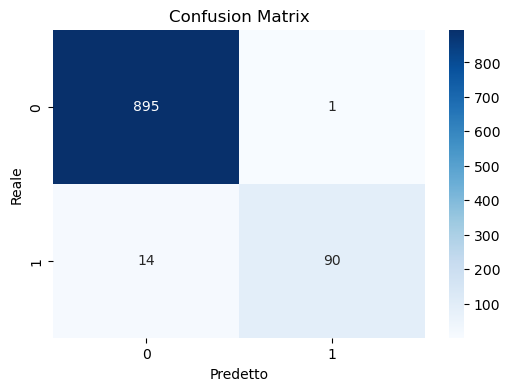

In [1]:
import os

# 1. SET BACKEND (Deve essere fatto prima di importare Keras)
os.environ["KERAS_BACKEND"] = "torch"

import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, f1_score
from sklearn.datasets import make_classification


# 1. ANALISI E GENERAZIONE DATI
# Generiamo un dataset sintetico sbilanciato (es. 90% classe 0, 10% classe 1)
# Teoria: Lo sbilanciamento è comune in medicina (malattie rare) o finanza (frodi).
X_raw, y_raw = make_classification(
    n_samples=5000, n_features=20, n_informative=15, 
    n_redundant=5, weights=[0.9, 0.1], random_state=42
)

# 2. STRATEGIA DI VALIDAZIONE (HOLD-OUT)
# Dividiamo in Training e Test set. 
# Importante: 'stratify' assicura che la proporzione delle classi sia identica nei due set.
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_raw, test_size=0.2, stratify=y_raw, random_state=42
)

# 3. PREPROCESSING: NORMALIZZAZIONE
# Teoria: Le reti neurali usano la discesa del gradiente. Feature con scale diverse
# rendono la loss function "allungata", rallentando o impedendo la convergenza.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # Calcola media/deviazione sul train e applica
X_test = scaler.transform(X_test)      # Applica i parametri del train (evita data leakage)

# 4. SCELTA DEL MODELLO: ARCHITETTURA ANN
# Optiamo per una struttura a imbuto con Dropout per contrastare l'overfitting.
model = keras.Sequential([
    # Layer di input: 20 neuroni corrispondenti alle feature
    keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    # Dropout: spegne casualmente il 20% dei neuroni per forzare la rete a essere robusta
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    # Output layer: 1 neurone con attivazione Sigmoide per probabilità [0, 1]
    keras.layers.Dense(1, activation='sigmoid')
])

# Compilazione: usiamo Adam (ottimizzatore adattivo) e BinaryCrossentropy
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. TRAINING CON EARLY STOPPING
# Teoria: L'EarlyStopping interrompe il training quando la validation loss smette di migliorare.
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train, 
    epochs=50, batch_size=32, 
    validation_split=0.1, # Usiamo una parte del train per monitorare il training
    callbacks=[early_stop], verbose=0
)

# 6. VALUTAZIONE E METRICHE AVANZATE
# Teoria: In dataset sbilanciati, l'accuratezza può essere 90% solo predicendo sempre '0'.
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Visualizzazione Confusion Matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predetto')
plt.ylabel('Reale')
plt.title('Confusion Matrix')
plt.show()